# Analysis of your PlaSim data

| Variable | Number |
|----------|--------|
| ta       | 130    |
| ua       | 131    |
| va       | 132    |
| hus      | 133    |
| ps       | 134    |
| wap      | 135    |
| ts       | 139    |
| prl      | 142    |
| prc      | 143    |
| prsn     | 144    |
| hfss     | 146    |
| hfls     | 147    |
| tas      | 167    |
| evap     | 182    |
| prw      | 230    |
| spd      | 259    |
| pr       | 260    |


### import packages: 

In [9]:
# data handling
import numpy as np
import datetime
import netCDF4
import xarray as xr

# plotting
import matplotlib.pyplot as plt
from matplotlib import cm

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# statistical analysis
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import ccf
from scipy.signal import welch, periodogram

# fitting
from scipy.optimize import curve_fit

In [10]:
#define dictionary for easy data access later on

filepath = '/home/yasin-b/Dokumente/GitHub/Juniorakademie_25/Data/'

Data_Monthly = {'280':netCDF4.Dataset(filepath + 'Out_monthly_last70yrs_280.nc'),
              '350':netCDF4.Dataset(filepath + 'Out_monthly_last70yrs_350.nc'),
              '450':netCDF4.Dataset(filepath + 'Out_monthly_last70yrs_450.nc'),
              '650':netCDF4.Dataset(filepath + 'Out_monthly_last70yrs_650.nc'),
              '850':netCDF4.Dataset(filepath + 'Out_monthly_last70yrs_850.nc'),
              '1150':netCDF4.Dataset(filepath + 'Out_monthly_last70yrs_1150.nc')
}

Data_Daily = {'280':netCDF4.Dataset(filepath + 'Out_daily_last10yrs_280.nc'),
                '350':netCDF4.Dataset(filepath + 'Out_daily_last10yrs_350.nc'),
                '450':netCDF4.Dataset(filepath + 'Out_daily_last10yrs_450.nc'),
                '650':netCDF4.Dataset(filepath + 'Out_daily_last10yrs_650.nc'),
                '850':netCDF4.Dataset(filepath + 'Out_daily_last10yrs_850.nc'),
                '1150':netCDF4.Dataset(filepath + 'Out_daily_last10yrs_1150.nc')
}


### inspect the data objects

In [11]:
print(Data_Daily['280'].variables['ta'])

<class 'netCDF4.Variable'>
float32 ta(time, lev, lat, lon)
    long_name: air_temperature
    standard_name: air_temperature
    units: K
    code: 130
    grid_type: gaussian
unlimited dimensions: time
current shape = (3600, 7, 32, 64)
filling on, default _FillValue of 9.969209968386869e+36 used


In [12]:
print(Data_Daily['280'].variables['ta'].dimensions)
print(Data_Daily['280'].variables['prsn'].shape)


('time', 'lev', 'lat', 'lon')
(3600, 32, 64)


In [13]:
type(Data_Monthly['280']['tas'])

netCDF4._netCDF4.Variable

In [14]:
print(Data_Monthly['280'].variables.keys())

dict_keys(['lon', 'lat', 'lev', 'time', 'ta', 'ua', 'va', 'hus', 'ps', 'wap', 'ts', 'prl', 'prc', 'prsn', 'hfss', 'hfls', 'tas', 'evap', 'prw', 'spd', 'pr'])


### Define some functions that might be useful later

In [15]:
def global_weighted_average(nc_data, var_name, last_timepoints):
    """
    Compute area-weighted global mean over the last N time steps.
    
    Parameters
    ----------
    nc_data : netCDF4.Dataset
        NetCDF dataset containing the variable.
    var_name : str
        Name of the variable (e.g., 'tas').
    last_timepoints : int
        Number of last time steps to include.
        
    Returns
    -------
    1D masked array (shape: time,) with global mean values.
    """
    data = nc_data.variables[var_name][-last_timepoints:]  # shape: (time, lat, lon)
    lat = nc_data.variables['lat'][:]
    weights = np.cos(np.deg2rad(lat))  # shape: (lat,)

    zonal_mean = np.ma.mean(data, axis=2)  # shape: (time, lat)
    global_mean = np.ma.average(zonal_mean, axis=1, weights=weights)  
    
    return global_mean

def global_time_average(nc_data, var_name, last_timepoints):
    """
    averages temporal mean for a given time period

    """
    return np.ma.average(global_weighted_average(nc_data, var_name, last_timepoints), axis=0)

def convertPrec(precArray):
    """
    Converts precipitation flux from kg/m^2/s (PlaSim output) to mm/year
    Simply devide by water density 1000 kg/m^3
    """
    return precArray *(360*24*60*60)

def zonal_mean(nc_data, var_name, last_timepoints):
    return np.ma.average(nc_data.variables[var_name][-last_timepoints:], axis=2)

def zonal_mean_time(nc_data, var_name, last_timepoints):
    return np.ma.average(zonal_mean(nc_data, var_name, last_timepoints), axis=0)


### Some plots

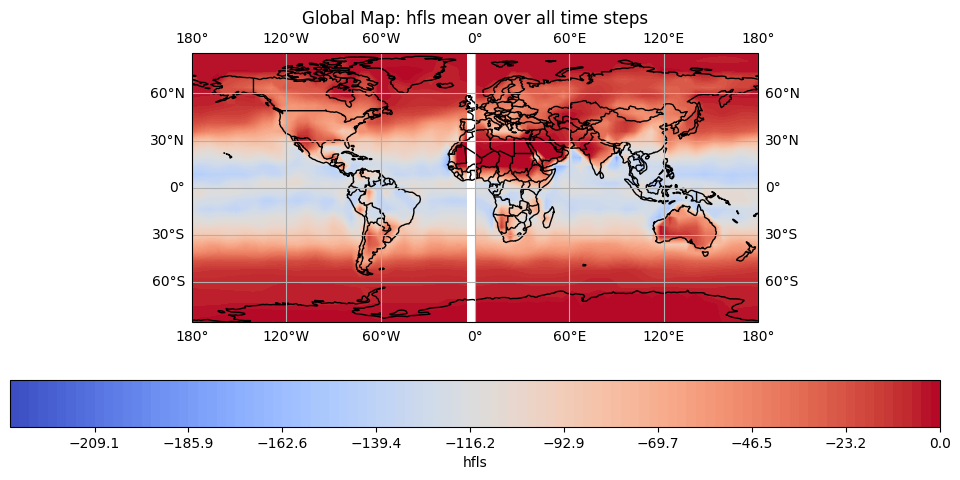

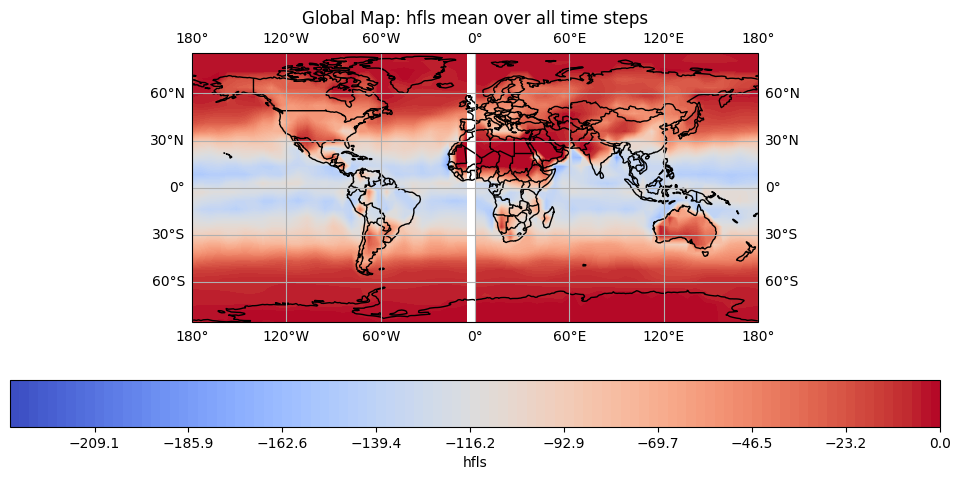

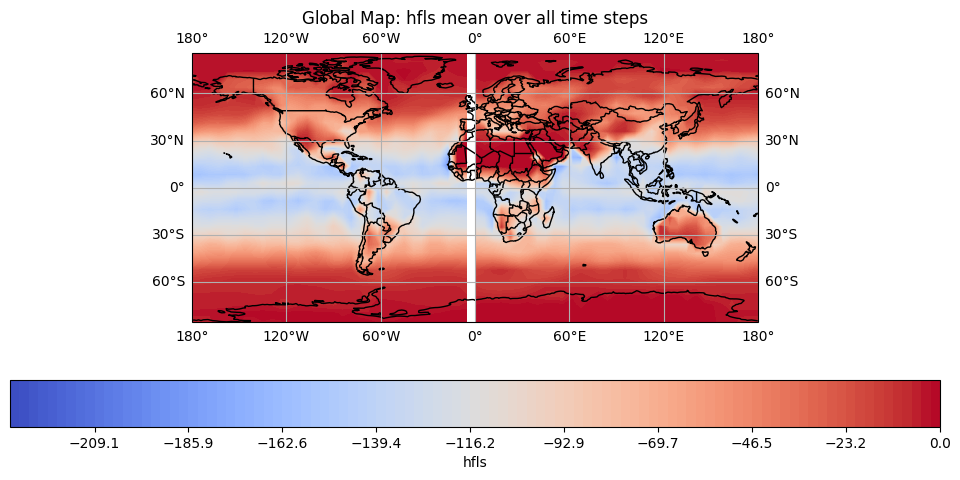

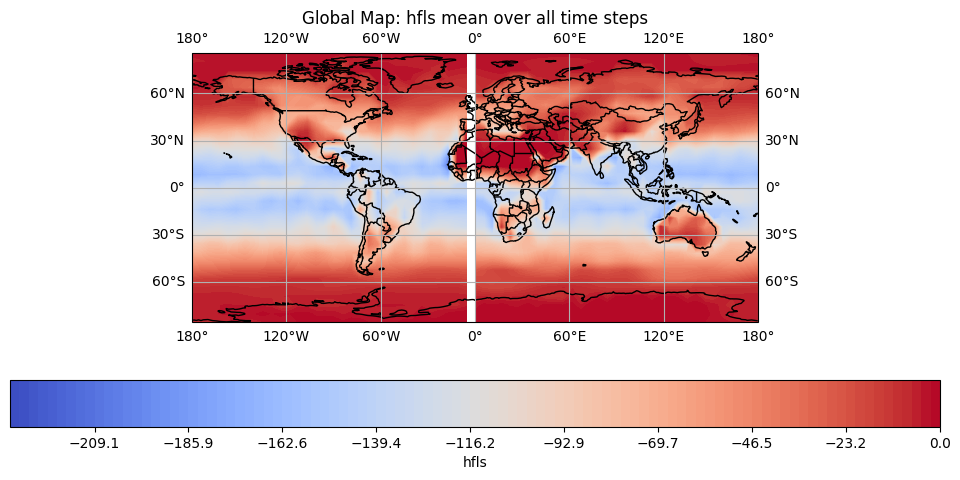

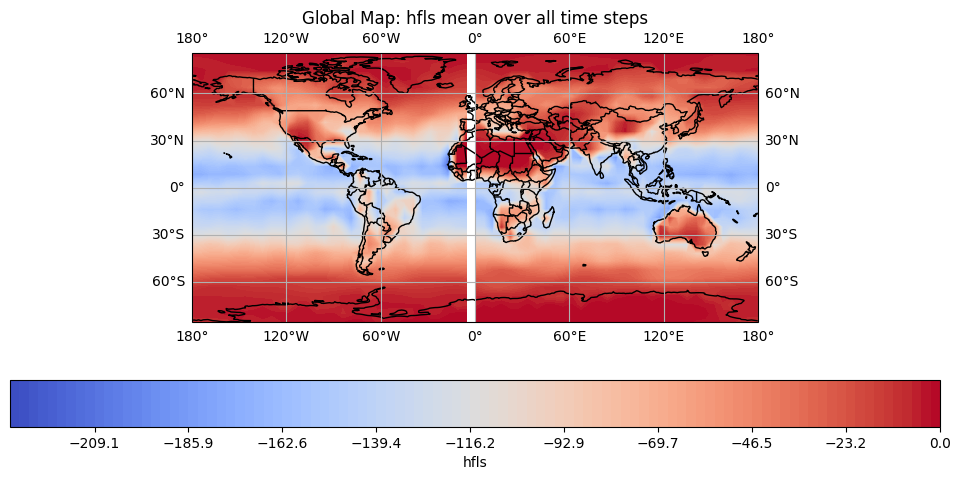

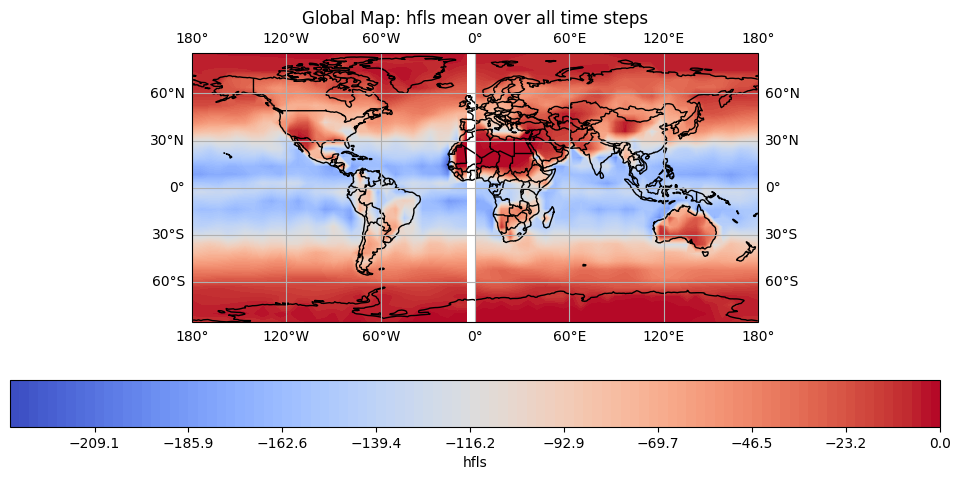

In [16]:

""""
def plot_global_map(nc_data, var_name, time_index=-1, cmap='coolwarm'):
    data = nc_data.variables[var_name][time_index]
    lons = nc_data.variables['lon'][:]
    lats = nc_data.variables['lat'][:]
    
    fig = plt.figure(figsize=(12, 5))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.gridlines(draw_labels=True)

    mesh = ax.contourf(lons, lats, data, 60, transform=ccrs.PlateCarree(),
    #                   levels=np.linspace(190, 310, part),
                       cmap=cmap)
    plt.colorbar(mesh, orientation='horizontal', label=f'{var_name}')
    plt.title(f'Global Map: {var_name} at time index {time_index}')
    plt.show()
"""

def plot_global_map_mean(nc_data, var_name, cmap='coolwarm'):
    data = nc_data.variables[var_name][:].mean(axis=0)  # Mean over all time steps
    lons = nc_data.variables['lon'][:]
    lats = nc_data.variables['lat'][:]
    
    fig = plt.figure(figsize=(12, 5))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.gridlines(draw_labels=True)

    mesh = ax.contourf(lons, lats, data, 60, transform=ccrs.PlateCarree(),
                       levels=np.linspace(-230, 0, 100),
                       cmap=cmap)
    plt.colorbar(mesh, orientation='horizontal', label=f'{var_name}')
    plt.title(f'Global Map: {var_name} mean over all time steps')
    plt.show()




# Example
parameter = 'hfls'  

#plot_global_map(Data_Daily['280'], parameter, time_index=0)  
#plot_global_map(Data_Daily['1150'], parameter, time_index=0)
plot_global_map_mean(Data_Daily['280'], parameter)
plot_global_map_mean(Data_Daily['350'], parameter)
plot_global_map_mean(Data_Daily['450'], parameter)
plot_global_map_mean(Data_Daily['650'], parameter)
plot_global_map_mean(Data_Daily['850'], parameter)
plot_global_map_mean(Data_Daily['1150'], parameter)

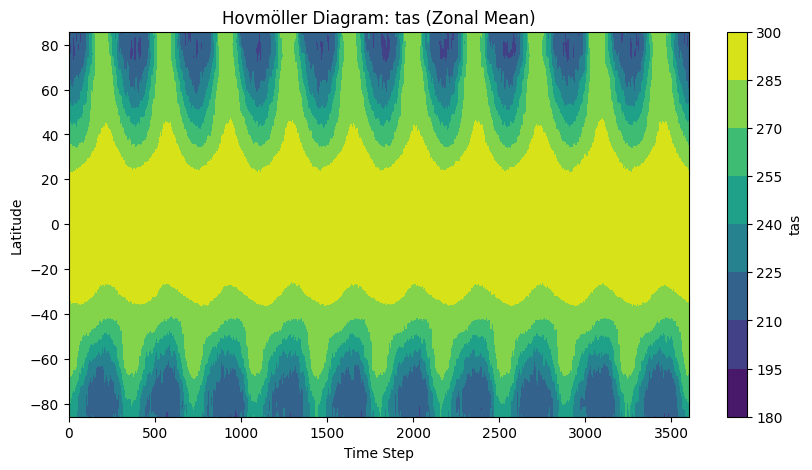

In [17]:
# Hovmöller Plot (Latitude vs Time, Zonal Mean)

def hovmoller_lat_time(nc_data, var_name, last_timepoints):
    data = zonal_mean(nc_data, var_name, last_timepoints)
    lat = nc_data.variables['lat'][:]
    
    plt.figure(figsize=(10, 5))
    plt.contourf(np.arange(data.shape[0]), lat, data.T, cmap='viridis')
    plt.xlabel('Time Step')
    plt.ylabel('Latitude')
    plt.title(f'Hovmöller Diagram: {var_name} (Zonal Mean)')
    plt.colorbar(label=var_name)
    plt.show()

# Example
hovmoller_lat_time(Data_Daily['280'], 'tas', 3600)


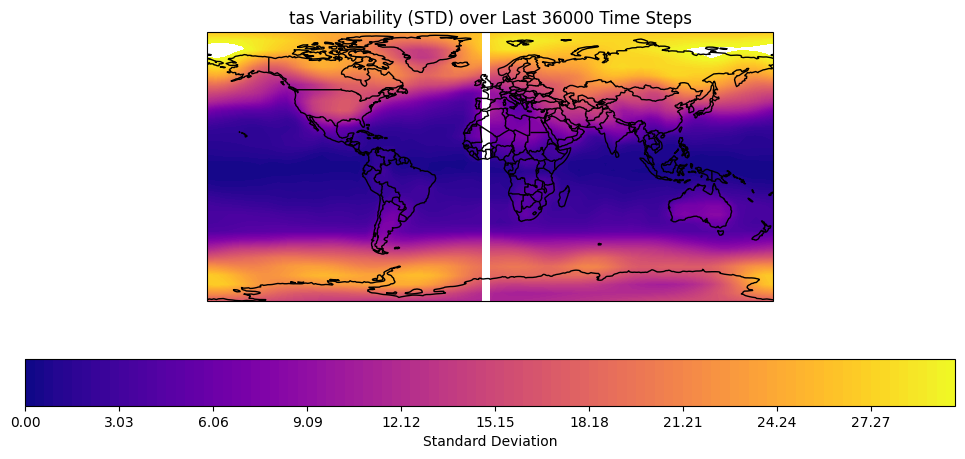

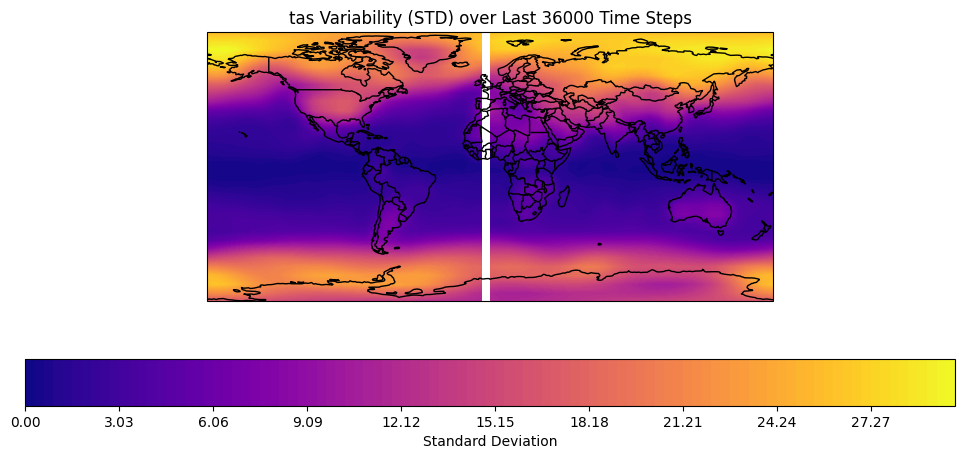

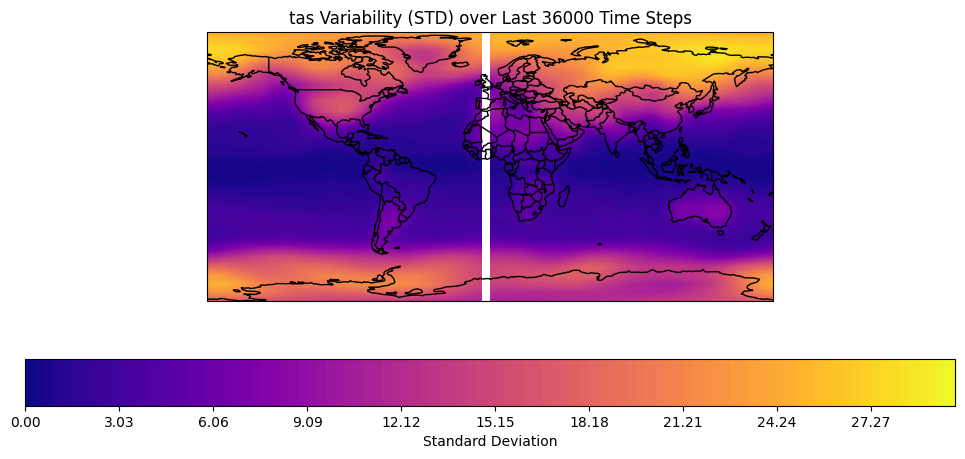

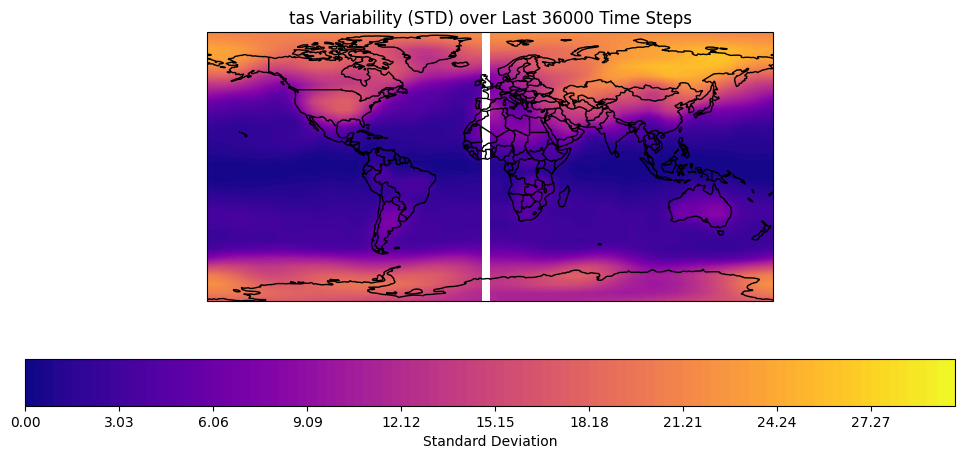

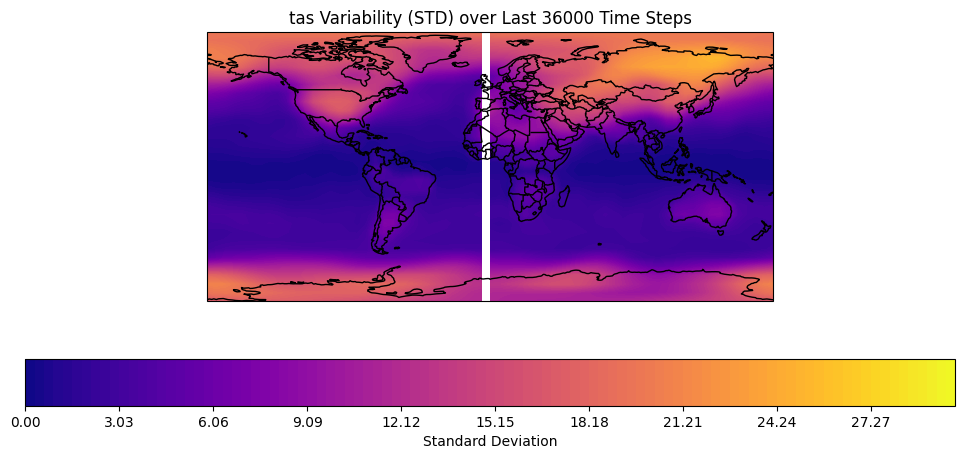

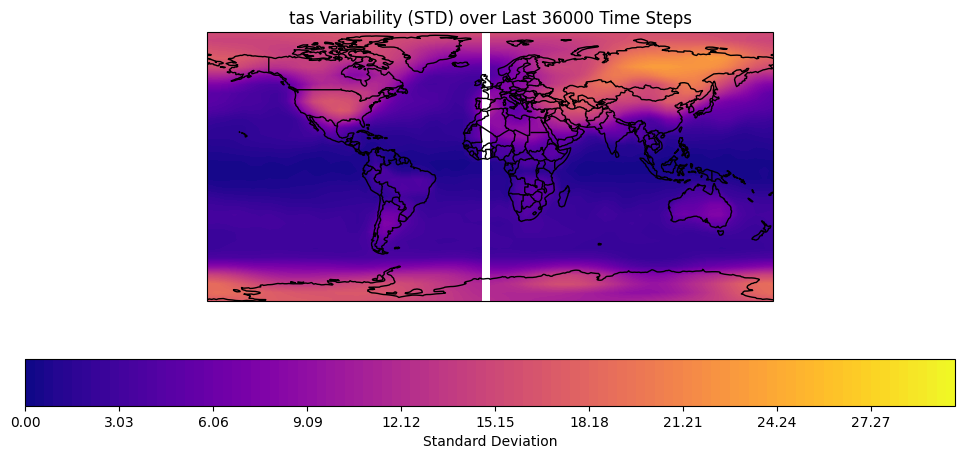

In [18]:
# Variability - Standard Deviation Map

def plot_std_map(nc_data, var_name, last_timepoints):
    data = nc_data.variables[var_name][-last_timepoints:]  # (time, lat, lon)
    std_data = np.ma.std(data, axis=0)

    lons = nc_data.variables['lon'][:]
    lats = nc_data.variables['lat'][:]

    fig = plt.figure(figsize=(12, 5))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    mesh = ax.contourf(lons, lats, std_data, 60, transform=ccrs.PlateCarree(), 
                       levels=np.linspace(0, 30, 100),
                       cmap='plasma')
    plt.colorbar(mesh, orientation='horizontal', label='Standard Deviation')
    plt.title(f'{var_name} Variability (STD) over Last {last_timepoints} Time Steps')
    plt.show()

# Example
var="tas"
plot_std_map(Data_Daily['280'], var, 36000)
plot_std_map(Data_Daily['350'], var, 36000)
plot_std_map(Data_Daily['450'], var, 36000)
plot_std_map(Data_Daily['650'], var, 36000)
plot_std_map(Data_Daily['850'], var, 36000)
plot_std_map(Data_Daily['1150'], var, 36000)


### is something is not working out, try help()

In [19]:
help(plt.pcolormesh)

Help on function pcolormesh in module matplotlib.pyplot:

pcolormesh(
    *args: ArrayLike,
    alpha: float | None = None,
    norm: str | Normalize | None = None,
    cmap: str | Colormap | None = None,
    vmin: float | None = None,
    vmax: float | None = None,
    colorizer: Colorizer | None = None,
    shading: Literal['flat', 'nearest', 'gouraud', 'auto'] | None = None,
    antialiased: bool = False,
    data=None,
    **kwargs
) -> QuadMesh
    Create a pseudocolor plot with a non-regular rectangular grid.

    Call signature::

        pcolormesh([X, Y,] C, /, **kwargs)

    *X* and *Y* can be used to specify the corners of the quadrilaterals.

    The arguments *X*, *Y*, *C* are positional-only.

    .. hint::

       `~.Axes.pcolormesh` is similar to `~.Axes.pcolor`. It is much faster
       and preferred in most cases. For a detailed discussion on the
       differences see :ref:`Differences between pcolor() and pcolormesh()
       <differences-pcolor-pcolormesh>`.

    Pa

In [22]:
# Load data with xarray(example: daily data with pressure levels)
ds = xr.open_dataset(filepath + 'Out_daily_last10yrs_1150.nc')

print(ds)

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 3600, lev: 7, lat: 32, lon: 64)
Coordinates:
  * time     (time) object 29kB 1989-01-01 00:00:00 ... 1998-12-30 00:00:00
  * lev      (lev) float64 56B 100.0 200.0 300.0 500.0 700.0 850.0 1e+03
  * lat      (lat) float64 256B 85.76 80.27 74.74 69.21 ... -74.74 -80.27 -85.76
  * lon      (lon) float64 512B 0.0 5.625 11.25 16.88 ... 343.1 348.8 354.4
Data variables: (12/17)
    ta       (time, lev, lat, lon) float32 206MB ...
    ua       (time, lev, lat, lon) float32 206MB ...
    va       (time, lev, lat, lon) float32 206MB ...
    hus      (time, lev, lat, lon) float32 206MB ...
    ps       (time, lat, lon) float32 29MB ...
    wap      (time, lev, lat, lon) float32 206MB ...
    ...       ...
    hfls     (time, lat, lon) float32 29MB ...
    tas      (time, lat, lon) float32 29MB ...
    evap     (time, lat, lon) float32 29MB ...
    prw      (time, lat, lon) float32 29MB ...
    spd      (time, lev, lat, lon) float32 206MB ...
    pr 

In [23]:
# Select Zonal Wind (ua) at 500 hPa

# Check levels (e.g., pressure levels like [1000, 850, ..., 10])
print(ds['lev'].values)

# Select 500 hPa
ua_500 = ds['ua'].sel(lev=500)


# Shape: (time, lat, lon)
print(ua_500.shape)


[ 100.  200.  300.  500.  700.  850. 1000.]
(3600, 32, 64)


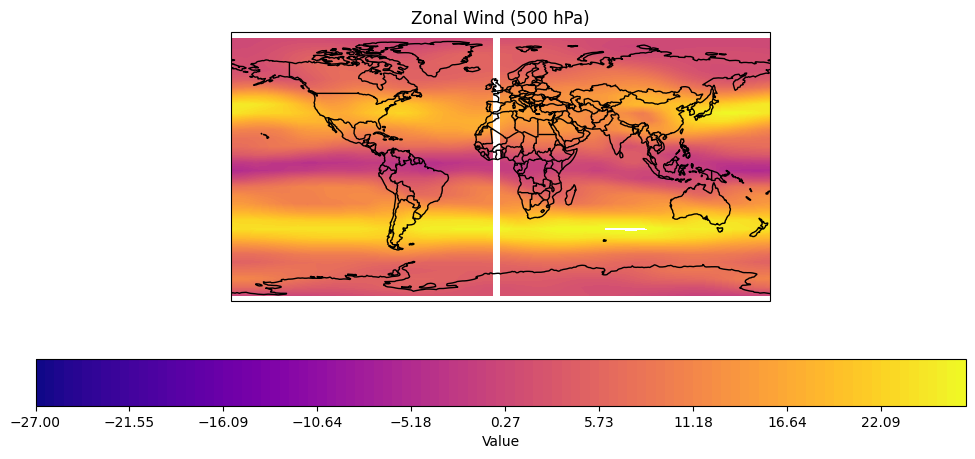

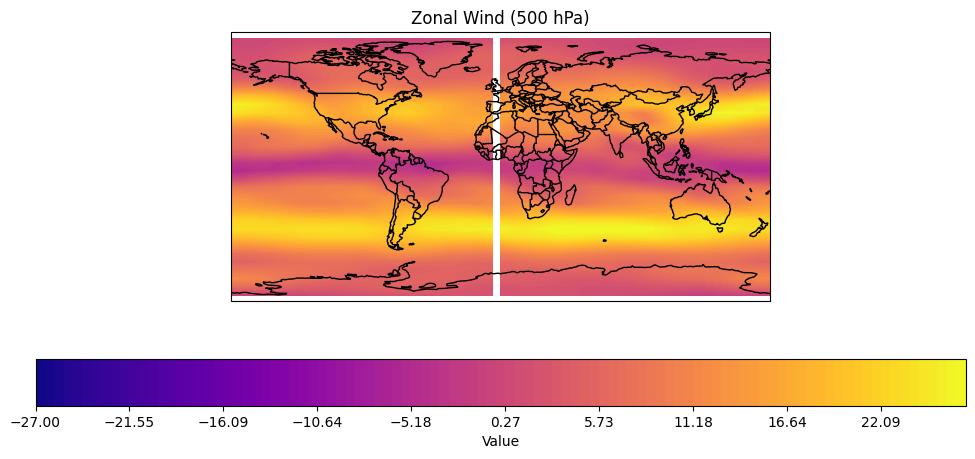

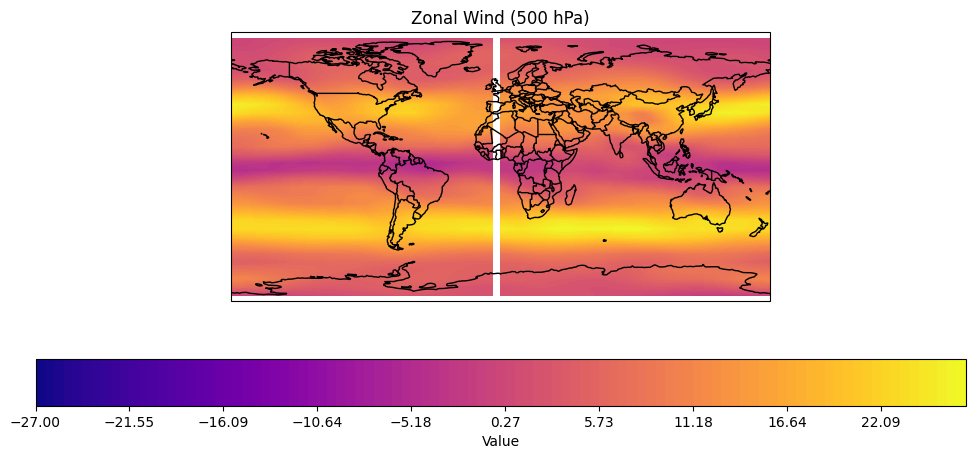

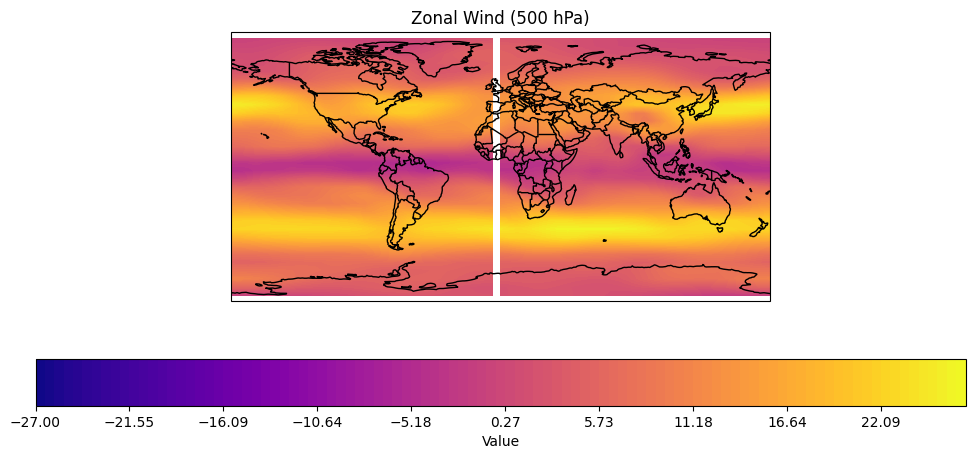

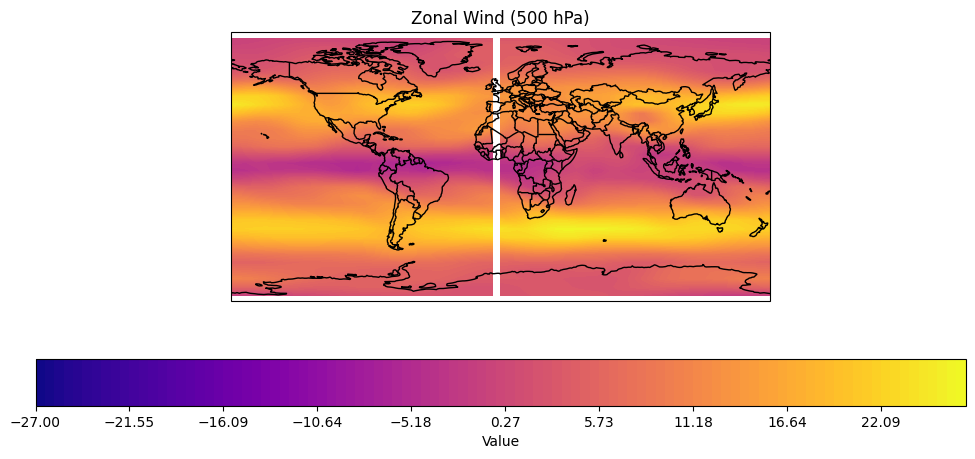

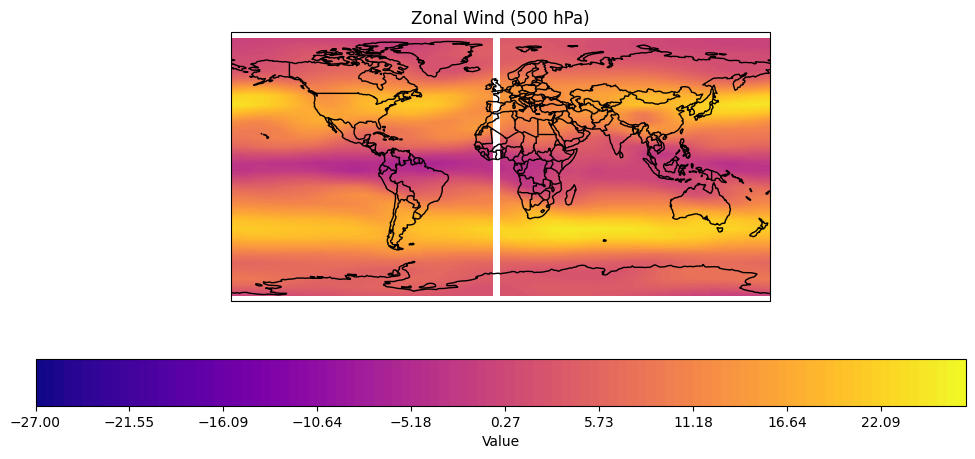

In [25]:
# Plot Global Map at a Single Time Step (e.g., time[0])

""""
def plot_global_wind_map(data_2d, lons, lats, title='Zonal Wind', cmap='RdBu_r'):
    fig = plt.figure(figsize=(12, 5))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.set_global()

    mesh = ax.contourf(lons, lats, data_2d, 60, transform=ccrs.PlateCarree(),
                        levels =np.linspace(-30, 30, 100),
                        cmap=cmap)
    plt.colorbar(mesh, orientation='horizontal', label='m/s')
    plt.title(title)
    plt.show()

    
def plot_std_map(nc_data, var_name, last_timepoints):
    data = nc_data.variables[var_name][-last_timepoints:]  # (time, lat, lon)
    std_data = np.ma.std(data, axis=0)

    lons = nc_data.variables['lon'][:]
    lats = nc_data.variables['lat'][:]

    fig = plt.figure(figsize=(12, 5))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    mesh = ax.contourf(lons, lats, std_data, 60, transform=ccrs.PlateCarree(), 
                       levels=np.linspace(0, 1.5e-7, 100),
                       cmap='plasma')
    plt.colorbar(mesh, orientation='horizontal', label='Standard Deviation')
    plt.title(f'{var_name} Variability (STD) over Last {last_timepoints} Time Steps')
    plt.show()
    """

def plot_std_map_from_array(data, lons, lats, last_timepoints=None, title='Standard Deviation Map', cmap='plasma'):

    # Falls xarray-Objekt → zu NumPy konvertieren
    if hasattr(data, "values"):
        data = data.values
    if hasattr(lons, "values"):
        lons = lons.values
    if hasattr(lats, "values"):
        lats = lats.values

    # Falls 3D-Daten → Standardabweichung
    if data.ndim == 3:
        if last_timepoints is not None:
            data = data[-last_timepoints:]
        data_2d = np.ma.std(data, axis=0)
    elif data.ndim == 2:
        data_2d = data
    else:
        raise ValueError("Data must be 2D or 3D (time, lat, lon).")

    # Plot
    fig = plt.figure(figsize=(12, 5))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.set_global()

    mesh = ax.contourf(lons, lats, data_2d, 60, transform=ccrs.PlateCarree(),
                       levels=np.linspace(-27, 27, 100),
                       cmap=cmap)
    plt.colorbar(mesh, orientation='horizontal', label='Value')
    plt.title(title)
    plt.show()


# Plot first timestep of ua at 500 hPa
ds = xr.open_dataset(filepath + 'Out_daily_last10yrs_280.nc')
ua_500 = ds['ua'].sel(lev=500)
plot_std_map_from_array(ua_500.mean(axis=0), ds['lon'], ds['lat'], title='Zonal Wind (500 hPa)')

ds = xr.open_dataset(filepath + 'Out_daily_last10yrs_350.nc')
ua_500 = ds['ua'].sel(lev=500)
plot_std_map_from_array(ua_500.mean(axis=0), ds['lon'], ds['lat'], title='Zonal Wind (500 hPa)')

ds = xr.open_dataset(filepath + 'Out_daily_last10yrs_450.nc')
ua_500 = ds['ua'].sel(lev=500)
plot_std_map_from_array(ua_500.mean(axis=0), ds['lon'], ds['lat'], title='Zonal Wind (500 hPa)')

ds = xr.open_dataset(filepath + 'Out_daily_last10yrs_650.nc')
ua_500 = ds['ua'].sel(lev=500)
plot_std_map_from_array(ua_500.mean(axis=0), ds['lon'], ds['lat'], title='Zonal Wind (500 hPa)')

ds = xr.open_dataset(filepath + 'Out_daily_last10yrs_850.nc')
ua_500 = ds['ua'].sel(lev=500)
plot_std_map_from_array(ua_500.mean(axis=0), ds['lon'], ds['lat'], title='Zonal Wind (500 hPa)')

ds = xr.open_dataset(filepath + 'Out_daily_last10yrs_1150.nc')
ua_500 = ds['ua'].sel(lev=500)
plot_std_map_from_array(ua_500.mean(axis=0), ds['lon'], ds['lat'], title='Zonal Wind (500 hPa)')

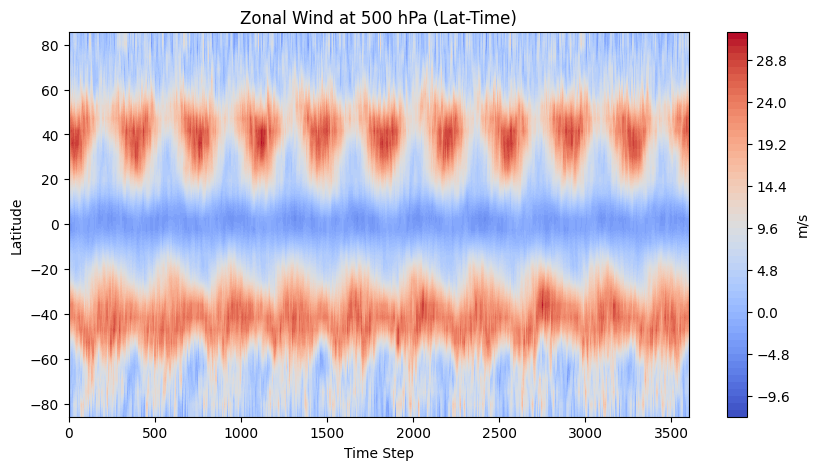

In [26]:
def hovmoller_lat_time_xr(da, title='Hovmöller', cmap='coolwarm'):
    # Compute zonal mean (time, lat)
    zonal_mean = da.mean(dim='lon')

    # Extract time and latitude axes
    time = zonal_mean['time'].values  # <- cftime format. xarray recognises non-Gregorian calendars (here: 360 days/year) and stores them in that format, which can't be used for axes 
    lat = zonal_mean['lat'].values

    # Convert cftime to numeric index 
    time_numeric = np.arange(len(time))  # Just use integer time axis for plotting

    # Plot
    plt.figure(figsize=(10, 5))
    plt.contourf(time_numeric, lat, zonal_mean.T, 60, cmap=cmap)
    plt.xlabel('Time Step')
    plt.ylabel('Latitude')
    plt.title(title)
    plt.colorbar(label='m/s')
    plt.show()

hovmoller_lat_time_xr(ua_500, title='Zonal Wind at 500 hPa (Lat-Time)')


KeyError: "No variable named ''. Variables on the dataset include ['ta', 'ua', 'va', 'hus', 'ps', ..., 'pr', 'lon', 'lat', 'lev', 'time']"

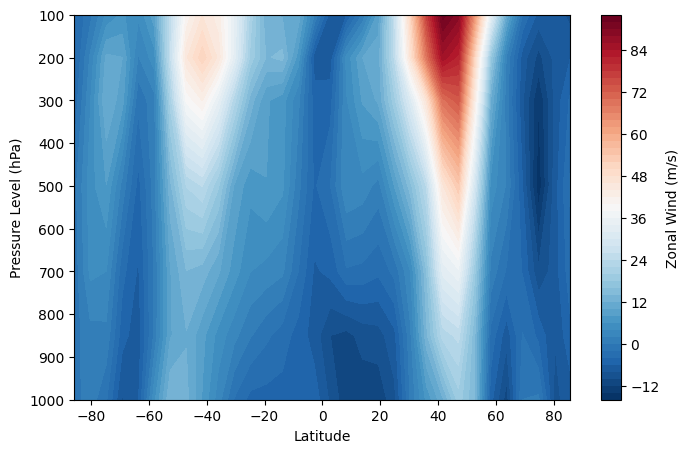

In [27]:
# Vertical Cross-Section — Zonal Wind vs Latitude & Pressure

def plot_vertical_cross_section(ds, time_index=0, lon_index=32):  # pick a central longitude
    ua = ds['ua'].isel(time=time_index, lon=lon_index)  # shape: (lev, lat)
    levs = ds['lev']
    lats = ds['lat']

    plt.figure(figsize=(8, 5))
    plt.contourf(lats, levs, ua, levels=60, cmap='RdBu_r')
    plt.gca().invert_yaxis()  # pressure decreases upward
    plt.colorbar(label='Zonal Wind (m/s)')
    plt.xlabel('Latitude')
    plt.ylabel('Pressure Level (hPa)')
    plt.title(f'Vertical Cross-Section of Zonal Wind (lon={ds[""][lon_index].values:.1f}°)')
    plt.show()

# Example:
plot_vertical_cross_section(ds, time_index=0, lon_index=32)

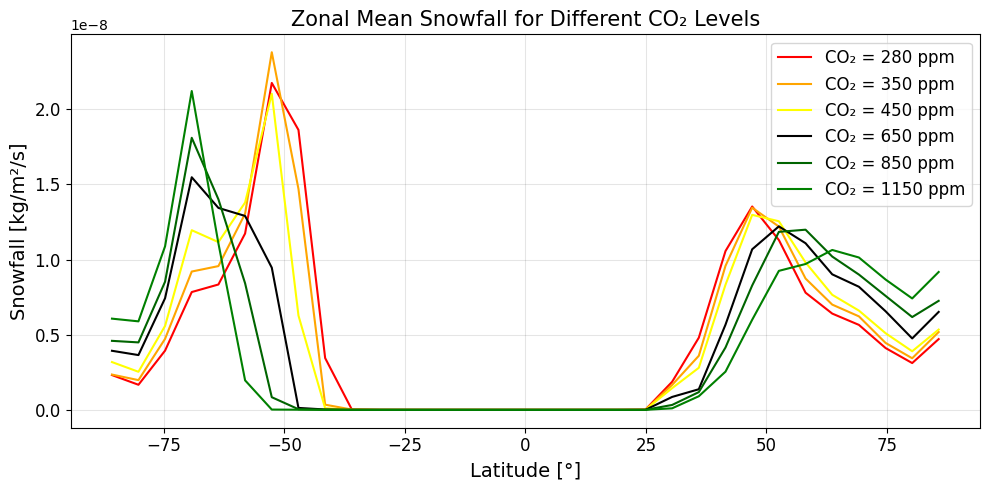

In [ ]:
var_name = 'prsn'  
var_label = 'Snowfall'  
units = 'kg/m²/s'      

# Custom color list
colorDict = ['red', 'orange', 'yellow', 'black', 'darkgreen', 'green', 'blue', 'darkblue']

# Create plot
fig, ax = plt.subplots(figsize=(10, 5))

for ind, co2_key in enumerate(sorted(Data_Daily.keys(), key=float)):
    ds = Data_Daily[co2_key]
    
    # Get variable and latitudes
    var = ds.variables[var_name][:]        # shape: (time, lat, lon)
    lat = ds.variables['lat'][:]           # shape: (lat,)
    
    # Compute zonal mean (mean over longitude)
    zonal_mean = np.mean(var, axis=2)      # shape: (time, lat)
    
    # Then mean over time
    zonal_mean_mean_time = np.mean(zonal_mean, axis=0)  # shape: (lat,)
    
    # Plot
    ax.plot(lat, zonal_mean_mean_time, label=f'CO₂ = {co2_key} ppm', color=colorDict[ind % len(colorDict)])

# Style the plot
ax.grid(axis='both', color='black', alpha=0.1)
ax.set_xlabel('Latitude [°]', fontsize=14)
ax.set_ylabel(f'{var_label} [{units}]', fontsize=14)
ax.set_title(f'Zonal Mean {var_label} for Different CO₂ Levels', fontsize=15)
ax.tick_params(axis='both', labelsize=12)
ax.legend(loc='best', fontsize=12)

plt.tight_layout()
#plt.savefig('plots/zonal_mean_CO2_levels.pdf')
plt.show()

In [ ]:
co2_levels = ['280', '350', '450', '650', '850', '1150']
colorDict = ['blue', 'green',  'black',  'yellow', 'orange', 'red' ]

var_name = 'tas'

# Store seasonal cycle
monthly_clim = {}

for co2_key in co2_levels:
    ds = Data_Monthly[co2_key]
    var = ds.variables[var_name][:]  # shape: (time, lat, lon)
    time = ds.variables['time'][:]   # usually months since a start date

    # Try to extract months
    try:
        time_units = ds.variables['time'].units
        calendar = ds.variables['time'].calendar if hasattr(ds.variables['time'], 'calendar') else 'standard'
        dates = netCDF4.num2date(time, units=time_units, calendar=calendar)
        months = np.array([date.month for date in dates])
    except:
        # Fallback for 360-day calendar with monthly data
        months = np.tile(np.arange(1, 13), len(time) // 12)

    # Compute global mean per time step
    global_means = global_weighted_average(ds, var_name, len(time))

    # Compute monthly climatology (average over all Januaries, Februaries, etc.)
    clim = [global_means[months == m].mean() for m in range(1, 13)]
    monthly_clim[co2_key] = clim

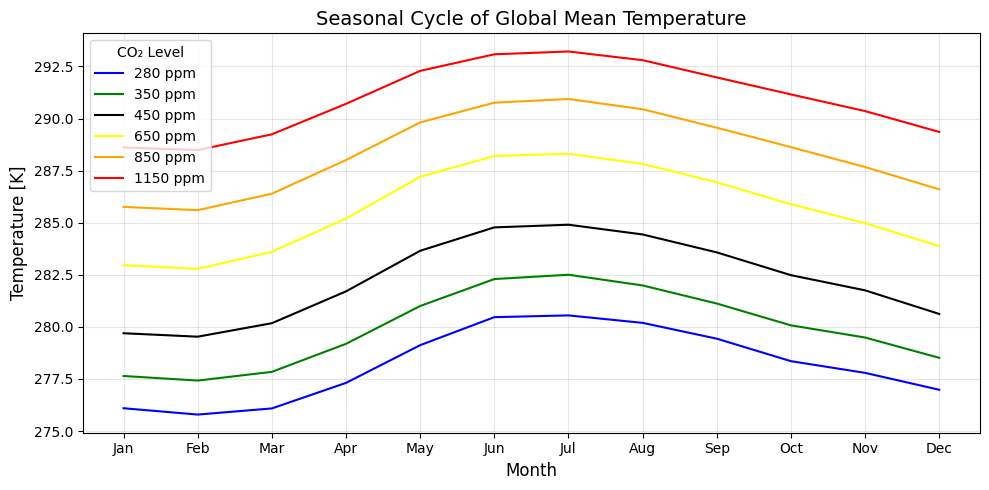

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
months_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for i, co2_key in enumerate(co2_levels):
    ax.plot(range(1, 13), monthly_clim[co2_key], label=f'{co2_key} ppm', color=colorDict[i])

ax.set_title('Seasonal Cycle of Global Mean Temperature', fontsize=14)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Temperature [K]', fontsize=12)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months_labels)
ax.legend(title='CO₂ Level')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### advanced: percentiles

In [ ]:
def compute_percentile_map(var_3d, percentile=90):
    """
    Computes the percentile value at each grid point over time.

    Parameters:
    -----------
    var_3d : np.ndarray
        Variable with shape (time, lat, lon)
    percentile : float
        Percentile to compute (e.g., 90)

    Returns:
    --------
    t_percentile : np.ndarray
        2D array (lat, lon) with the threshold value
    """
    return np.percentile(var_3d, percentile, axis=0)



In [ ]:
ds = Data_Daily['280']
tas = ds.variables['tas'][:]  # shape: (time, lat, lon)

t90_map = compute_percentile_map(tas, percentile=90)  # shape: (lat, lon)

/home/yasin-b/Schreibtisch/JA/.venv/lib64/python3.13/site-packages/numpy/lib/_function_base_impl.py:4859: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


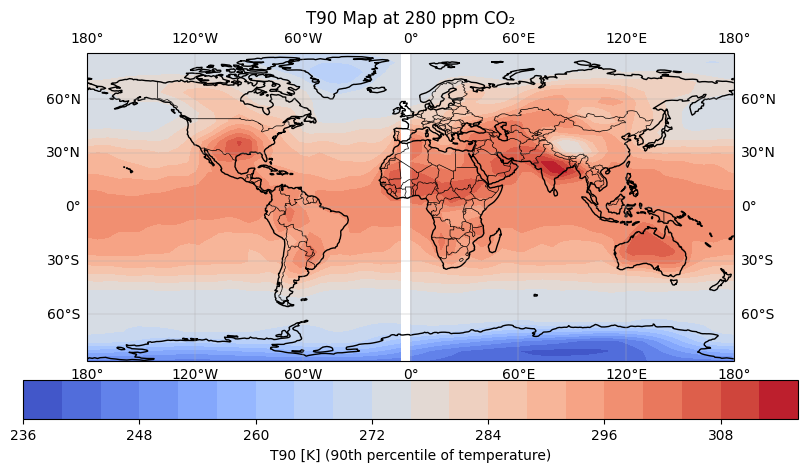

In [ ]:
lat = ds.variables['lat'][:]
lon = ds.variables['lon'][:]

plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
cf = ax.contourf(lon, lat, t90_map, levels=20, transform=ccrs.PlateCarree(), cmap='coolwarm')

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.gridlines(draw_labels=True, linewidth=0.3)

# Colorbar
cbar = plt.colorbar(cf, orientation='horizontal', pad=0.05)
cbar.set_label('T90 [K] (90th percentile of temperature)')

plt.title('T90 Map at 280 ppm CO₂')
plt.show()



In [ ]:
type(ds)

netCDF4._netCDF4.Dataset

In [ ]:

monthly_paths = {
    '280': filepath + 'Out_monthly_last70yrs_280.nc',
    '350': filepath + 'Out_monthly_last70yrs_350.nc',
    '450': filepath + 'Out_monthly_last70yrs_450.nc',
    '650': filepath + 'Out_monthly_last70yrs_650.nc',
    '850': filepath + 'Out_monthly_last70yrs_850.nc',
    '1150': filepath + 'Out_monthly_last70yrs_1150.nc'
}

daily_paths = {
    '280': filepath + 'Out_daily_last10yrs_280.nc',
    '350': filepath + 'Out_daily_last10yrs_350.nc',
    '450': filepath + 'Out_daily_last10yrs_450.nc',
    '650': filepath + 'Out_daily_last10yrs_650.nc',
    '850': filepath + 'Out_daily_last10yrs_850.nc',
    '1150': filepath + 'Out_daily_last10yrs_1150.nc'
}

Data_Monthly = {key: xr.open_dataset(path) for key, path in monthly_paths.items()}
Data_Daily   = {key: xr.open_dataset(path) for key, path in daily_paths.items()}


<>:23: SyntaxWarning: invalid escape sequence '\O'
<>:23: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_22100/4048165617.py:23: SyntaxWarning: invalid escape sequence '\O'
  ax100.set_title('$\Omega$ = '+ str(float(key[1:])/100), fontsize=19)


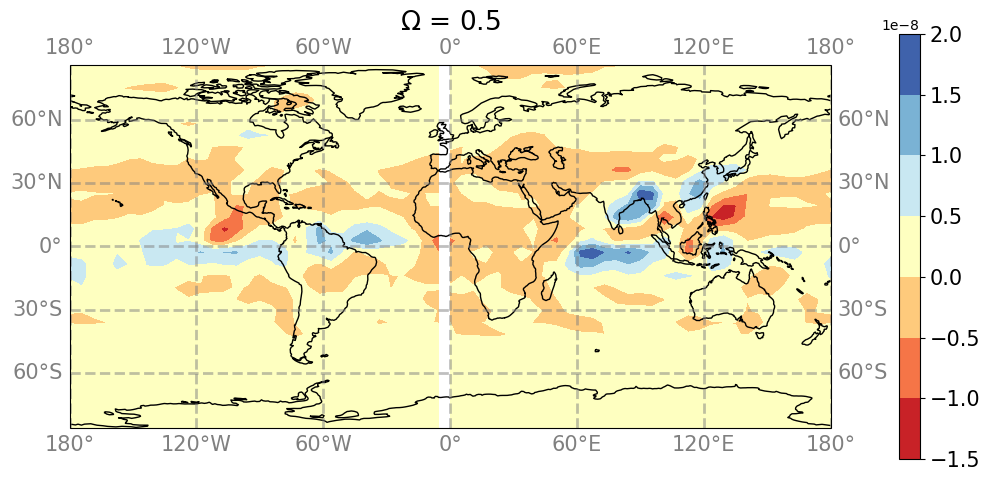

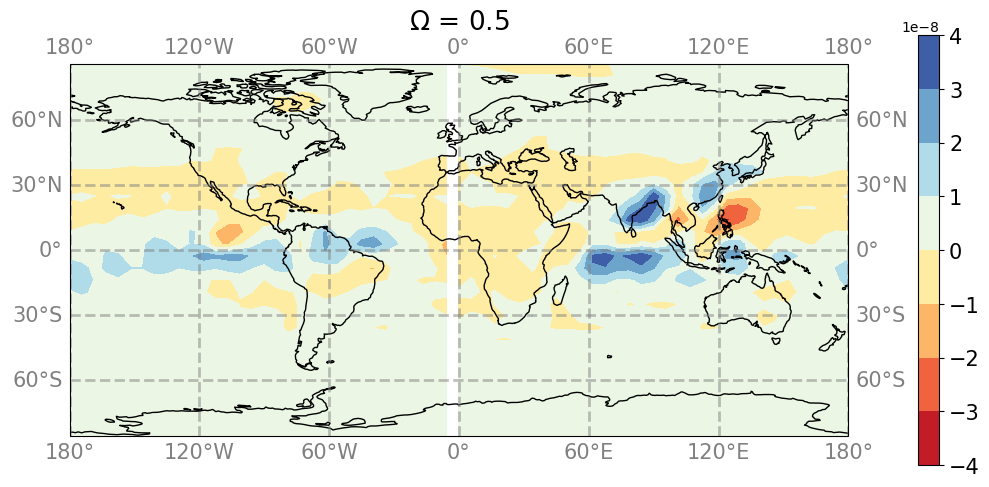

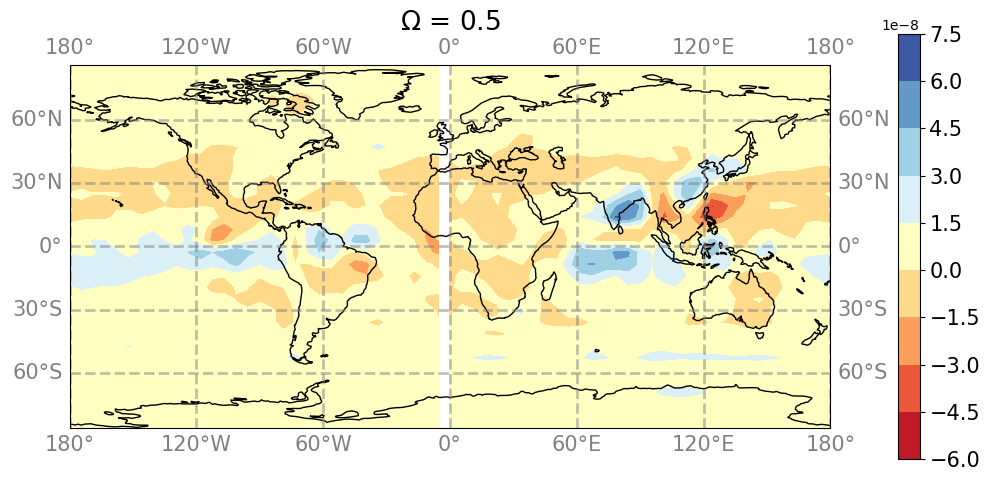

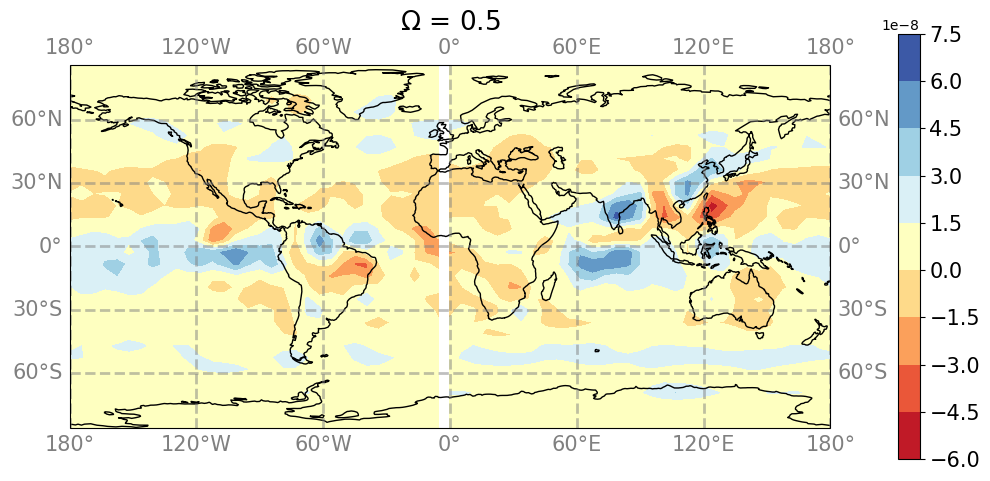

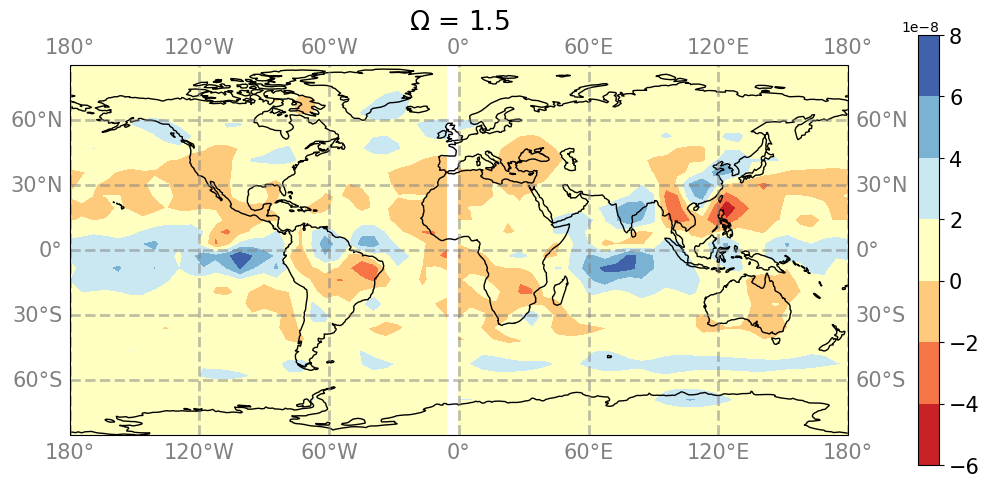

In [ ]:
for key in ['350', '450', '650', '850', '1150']:

    fig = plt.figure(figsize=(10,5))
    cmap = plt.get_cmap('RdYlBu')

    xArr, yArr = np.meshgrid(
    np.ma.filled(Data_Monthly['280'].variables['lon'][:]),
    np.ma.filled(Data_Monthly['280'].variables['lat'][:])
    )


    ax100 = plt.axes(projection=ccrs.PlateCarree())
    ax100.coastlines()
    contour = ax100.contourf(xArr, yArr, (Data_Monthly[key].variables['pr'].mean(dim='time')-Data_Monthly['280'].variables['pr'].mean(dim='time')), cmap=cmap) #ypu can put in , levels=[-4000, -1000, -500, 0, 500, 1000, 4000] for the bar, which you want 
    gl = ax100.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, 
                         linewidth=2, color='gray', alpha=0.5, linestyle='--')
    gl.xlabel_style = {'size': 15, 'color': 'gray'}
    gl.ylabel_style = {'size': 15, 'color': 'gray'}

    cbar = ax100.figure.colorbar(contour, ax=ax100, fraction=0.025, pad=0.08)
    cbar.ax.tick_params(labelsize=15)
#     ax100.set_title('Mean precipitation difference $\Delta$ Pr = Pr$_{'+str(float(key[1:])/100)+'}$ -Pr$_{1.00}$ [mm/yr]', fontsize=17)
    ax100.set_title('$\Omega$ = '+ str(float(key[1:])/100), fontsize=19)
    fig.tight_layout()
   # plt.savefig('plots/dpr'+key[1:]+'.pdf')
    plt.show()

In [ ]:
print(Data_Monthly['280'].variables.keys())


KeysView(Frozen({'ta': <xarray.Variable (time: 840, lev: 7, lat: 32, lon: 64)> Size: 48MB
[12042240 values with dtype=float32]
Attributes:
    long_name:      air_temperature
    standard_name:  air_temperature
    units:          K
    code:           130
    grid_type:      gaussian, 'ua': <xarray.Variable (time: 840, lev: 7, lat: 32, lon: 64)> Size: 48MB
[12042240 values with dtype=float32]
Attributes:
    long_name:      eastward_wind
    standard_name:  eastward_wind
    units:          m s-1
    code:           131
    grid_type:      gaussian, 'va': <xarray.Variable (time: 840, lev: 7, lat: 32, lon: 64)> Size: 48MB
[12042240 values with dtype=float32]
Attributes:
    long_name:      northward_wind
    standard_name:  northward_wind
    units:          m s-1
    code:           132
    grid_type:      gaussian, 'hus': <xarray.Variable (time: 840, lev: 7, lat: 32, lon: 64)> Size: 48MB
[12042240 values with dtype=float32]
Attributes:
    long_name:      specific_humidity
    standa

In [ ]:
np.shape(Data_Monthly['280'].variables['lon'][:])

(64,)

In [ ]:
np.shape(Data_Monthly['280'].variables['pr'].mean(dim='time'))

(32, 64)